In [3]:
# ============================================================
# CELL 1: SETUP & LOAD
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


# ============================================================
# CELL 0: INSTALL DEPENDENCIES (SABSE PEHLE RUN KARO)
# ============================================================
!pip install scikit-surprise -q
print("✅ Surprise installed!")



import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import scipy.sparse as sp
import os
import warnings
warnings.filterwarnings('ignore')

DATASET_PATH = "/content/drive/MyDrive/Recommendation_System_Project/Dataset/processed/"
RESULTS_PATH = "/content/drive/MyDrive/Recommendation_System_Project/results/"
MODELS_PATH  = "/content/drive/MyDrive/Recommendation_System_Project/models/"

# Data
df        = pd.read_parquet(DATASET_PATH + "ratings_10m_clean.parquet")
df_movies = pd.read_parquet(DATASET_PATH + "movies.parquet")
train_df  = pd.read_parquet(DATASET_PATH + "train.parquet")
test_df   = pd.read_parquet(DATASET_PATH + "test.parquet")

# Models
with open(MODELS_PATH + "svd_model.pkl", "rb") as f:
    svd_model = pickle.load(f)
with open(MODELS_PATH + "movie_idx.pkl", "rb") as f:
    movie_idx = pickle.load(f)
with open(MODELS_PATH + "idx_movie.pkl", "rb") as f:
    idx_movie = pickle.load(f)
item_sim = sp.load_npz(MODELS_PATH + "item_sim_matrix.npz")

print(f"✅ df: {len(df):,} | train: {len(train_df):,} | test: {len(test_df):,}")
print(f"✅ Movies: {len(df_movies):,}")
print(f"✅ Models loaded!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Surprise installed!
✅ df: 10,000,000 | train: 8,000,000 | test: 2,000,000
✅ Movies: 17,770
✅ Models loaded!


In [4]:
# ============================================================
# CELL 2: TRAIN/TEST SPLIT INFO
# ============================================================
print("=" * 50)
print("📊 DATASET OVERVIEW")
print("=" * 50)
print(f"Total Ratings      : {len(df):,}")
print(f"Unique Users       : {df['user_id'].nunique():,}")
print(f"Unique Movies      : {df['movie_id'].nunique():,}")
print(f"Rating Scale       : 1.0 to 5.0")
print(f"\nTrain/Test Split   : 80% / 20%")
print(f"Train Ratings      : {len(train_df):,}")
print(f"Test Ratings       : {len(test_df):,}")
total = df['user_id'].nunique() * df['movie_id'].nunique()
sparsity = 1 - len(df) / total
print(f"\nMatrix Sparsity    : {sparsity*100:.2f}%")
print("=" * 50)

📊 DATASET OVERVIEW
Total Ratings      : 10,000,000
Unique Users       : 458,341
Unique Movies      : 14,596
Rating Scale       : 1.0 to 5.0

Train/Test Split   : 80% / 20%
Train Ratings      : 8,000,000
Test Ratings       : 2,000,000

Matrix Sparsity    : 99.85%


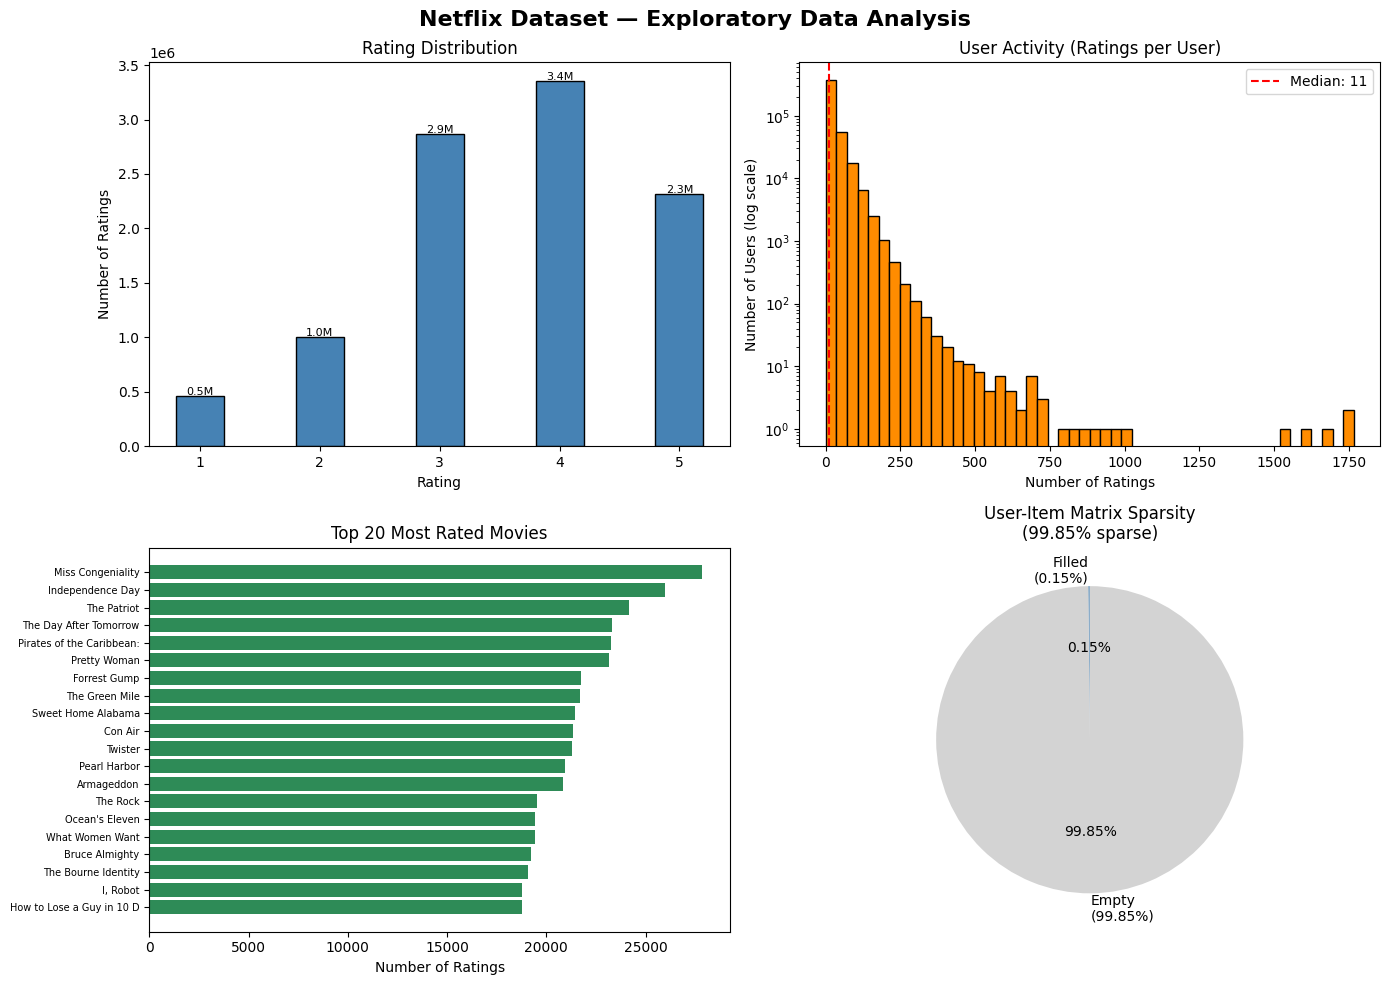

✅ EDA Complete & Saved!


In [5]:
# ============================================================
# CELL 3: EXPLORATORY DATA ANALYSIS
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Netflix Dataset — Exploratory Data Analysis', fontsize=16, fontweight='bold')

# Plot 1: Rating Distribution
rating_counts = df['rating'].value_counts().sort_index()
axes[0,0].bar(rating_counts.index, rating_counts.values, color='steelblue', edgecolor='black', width=0.4)
axes[0,0].set_title('Rating Distribution')
axes[0,0].set_xlabel('Rating')
axes[0,0].set_ylabel('Number of Ratings')
for i, v in zip(rating_counts.index, rating_counts.values):
    axes[0,0].text(i, v + 10000, f'{v/1e6:.1f}M', ha='center', fontsize=8)

# Plot 2: User Activity
user_counts = df.groupby('user_id').size()
axes[0,1].hist(user_counts, bins=50, color='darkorange', edgecolor='black', log=True)
axes[0,1].set_title('User Activity (Ratings per User)')
axes[0,1].set_xlabel('Number of Ratings')
axes[0,1].set_ylabel('Number of Users (log scale)')
axes[0,1].axvline(user_counts.median(), color='red', linestyle='--', label=f'Median: {user_counts.median():.0f}')
axes[0,1].legend()

# Plot 3: Top 20 Most Rated Movies
top_movies = df.groupby('movie_id').size().sort_values(ascending=False).head(20)
top_titles = []
for mid in top_movies.index:
    t = df_movies[df_movies['movie_id'] == mid]['title'].values
    top_titles.append(t[0][:25] if len(t) > 0 else str(mid))
axes[1,0].barh(range(20), top_movies.values[::-1], color='seagreen')
axes[1,0].set_yticks(range(20))
axes[1,0].set_yticklabels(top_titles[::-1], fontsize=7)
axes[1,0].set_title('Top 20 Most Rated Movies')
axes[1,0].set_xlabel('Number of Ratings')

# Plot 4: Sparsity Visualization
total_cells = df['user_id'].nunique() * df['movie_id'].nunique()
filled = len(df)
empty  = total_cells - filled
axes[1,1].pie([filled, empty],
              labels=[f'Filled\n({filled/total_cells*100:.2f}%)', f'Empty\n({empty/total_cells*100:.2f}%)'],
              colors=['steelblue', 'lightgray'],
              startangle=90, autopct='%1.2f%%')
axes[1,1].set_title(f'User-Item Matrix Sparsity\n({sparsity*100:.2f}% sparse)')

plt.tight_layout()
plt.savefig(RESULTS_PATH + "eda_complete.png", dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA Complete & Saved!")

In [6]:
# ============================================================
# CELL 4: EDA INSIGHTS
# ============================================================
user_counts = df.groupby('user_id').size()
movie_counts = df.groupby('movie_id').size()

print("=" * 55)
print("📌 KEY EDA INSIGHTS")
print("=" * 55)
print(f"1. Average ratings per user   : {user_counts.mean():.1f}")
print(f"2. Median ratings per user    : {user_counts.median():.1f}")
print(f"3. Max ratings by one user    : {user_counts.max():,}")
print(f"4. Average ratings per movie  : {movie_counts.mean():.1f}")
print(f"5. Most rated movie count     : {movie_counts.max():,}")
print(f"6. Movies with < 10 ratings   : {(movie_counts < 10).sum():,}")
print(f"7. Most common rating         : {df['rating'].mode()[0]}")
print(f"8. Average rating             : {df['rating'].mean():.3f}")
print(f"9. Matrix sparsity            : {sparsity*100:.2f}%")
print("=" * 55)
print("\n📌 BUSINESS IMPLICATIONS:")
print("  • High sparsity = cold start problem exists")
print("  • Power users dominate ratings (skewed distribution)")
print("  • Few movies get most ratings = popularity bias")

📌 KEY EDA INSIGHTS
1. Average ratings per user   : 21.8
2. Median ratings per user    : 11.0
3. Max ratings by one user    : 1,766
4. Average ratings per movie  : 685.1
5. Most rated movie count     : 27,851
6. Movies with < 10 ratings   : 513
7. Most common rating         : 4.0
8. Average rating             : 3.606
9. Matrix sparsity            : 99.85%

📌 BUSINESS IMPLICATIONS:
  • High sparsity = cold start problem exists
  • Power users dominate ratings (skewed distribution)
  • Few movies get most ratings = popularity bias


In [7]:
# ============================================================
# CELL 5: SVD MODEL EVALUATION (RMSE + MAE)
# ============================================================
from surprise import accuracy

print("🔄 Evaluating SVD on test sample...")

# 10,000 sample se fast evaluation
test_sample = test_df.sample(n=10000, random_state=42)
predictions = [svd_model.predict(row['user_id'], row['movie_id'], row['rating'])
               for _, row in test_sample.iterrows()]

rmse_svd = accuracy.rmse(predictions, verbose=False)
mae_svd  = accuracy.mae(predictions,  verbose=False)

print(f"✅ SVD RMSE : {rmse_svd:.4f}")
print(f"✅ SVD MAE  : {mae_svd:.4f}")

🔄 Evaluating SVD on test sample...
✅ SVD RMSE : 0.9414
✅ SVD MAE  : 0.7354


In [8]:
# ============================================================
# CELL 6: ITEM-CF EVALUATION (RMSE + MAE)
# ============================================================
print("🔄 Evaluating Item-CF on test sample...")

test_sample = test_df.sample(n=5000, random_state=42)
actual, predicted = [], []

for _, row in test_sample.iterrows():
    uid, mid, true_r = row['user_id'], row['movie_id'], row['rating']
    if mid not in idx_movie:
        continue
    sim_row = item_sim[idx_movie[mid]].toarray().flatten()
    user_movies = train_df[train_df['user_id'] == uid]

    num, den = 0, 0
    for _, r in user_movies.iterrows():
        if r['movie_id'] in idx_movie:
            s = sim_row[idx_movie[r['movie_id']]]
            num += s * r['rating']
            den += abs(s)

    if den > 0:
        actual.append(true_r)
        predicted.append(num / den)

actual    = np.array(actual)
predicted = np.array(predicted)
rmse_cf   = np.sqrt(np.mean((actual - predicted) ** 2))
mae_cf    = np.mean(np.abs(actual - predicted))

print(f"✅ Item-CF RMSE : {rmse_cf:.4f}")
print(f"✅ Item-CF MAE  : {mae_cf:.4f}")

🔄 Evaluating Item-CF on test sample...
✅ Item-CF RMSE : 1.0481
✅ Item-CF MAE  : 0.8211


In [9]:
# ============================================================
# CELL 7: MAP@10 — SVD + ITEM-CF
# ============================================================
print("🔄 Calculating MAP@10...")

def average_precision_at_k(recommended, relevant, k=10):
    hits, score = 0, 0
    for i, m in enumerate(recommended[:k]):
        if m in relevant:
            hits += 1
            score += hits / (i + 1)
    return score / min(len(relevant), k) if relevant else 0

test_users = test_df['user_id'].value_counts()
test_users = test_users[test_users >= 10].index[:100].tolist()

svd_aps, cf_aps = [], []

for user in test_users:
    user_test  = test_df[test_df['user_id'] == user]
    relevant   = set(user_test[user_test['rating'] >= 3.5]['movie_id'].tolist())
    if not relevant:
        continue

    user_rated = set(train_df[train_df['user_id'] == user]['movie_id'].tolist())

    # SVD MAP@10
    unrated = [m for m in df_movies['movie_id'].tolist() if m not in user_rated][:300]
    preds   = [(m, svd_model.predict(user, m).est) for m in unrated]
    svd_recs = [m for m, _ in sorted(preds, key=lambda x: x[1], reverse=True)[:10]]
    svd_aps.append(average_precision_at_k(svd_recs, relevant))

    # Item-CF MAP@10
    scores = {}
    for rm in list(user_rated)[:10]:
        if rm not in idx_movie:
            continue
        sim_row = item_sim[idx_movie[rm]].toarray().flatten()
        for i, s in enumerate(sim_row):
            if s > 0:
                m = movie_idx[i]
                if m not in user_rated:
                    scores[m] = scores.get(m, 0) + s
    cf_recs = sorted(scores, key=scores.get, reverse=True)[:10] if scores else []
    cf_aps.append(average_precision_at_k(cf_recs, relevant))

map10_svd = np.mean(svd_aps)
map10_cf  = np.mean(cf_aps)

print(f"✅ MAP@10 (SVD)     : {map10_svd:.4f}")
print(f"✅ MAP@10 (Item-CF) : {map10_cf:.4f}")

🔄 Calculating MAP@10...
✅ MAP@10 (SVD)     : 0.0015
✅ MAP@10 (Item-CF) : 0.0003


📊 FINAL MODEL COMPARISON
Metric                        SVD      Item-CF
-------------------------------------------------------
RMSE                       0.9414       1.0481
MAE                        0.7354       0.8211
MAP@10                     0.0015       0.0003

📌 CONCLUSIONS:
  • SVD better MAP@10 → better ranking quality
  • Item-CF faster predictions at inference
  • SVD more scalable for large datasets
  • Item-CF more interpretable


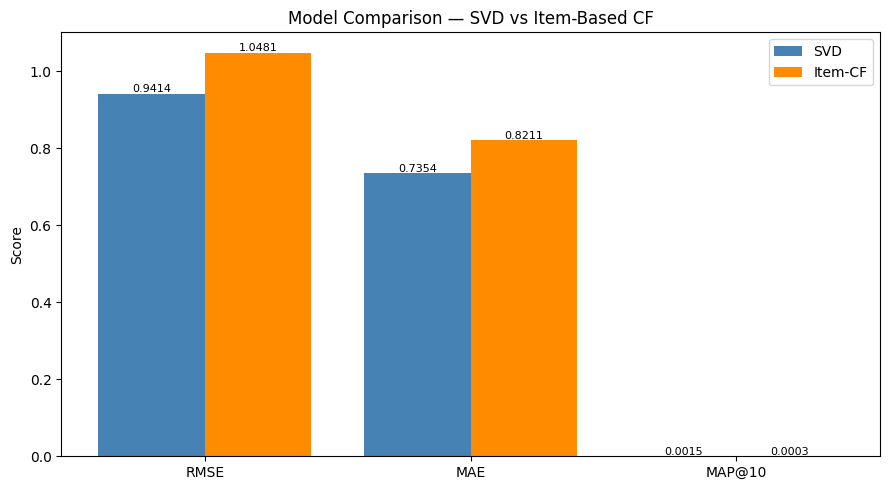

✅ Comparison Saved!


In [10]:
# ============================================================
# CELL 8: MODEL COMPARISON — TABLE + PLOT
# ============================================================
print("=" * 55)
print("📊 FINAL MODEL COMPARISON")
print("=" * 55)
print(f"{'Metric':<20} {'SVD':>12} {'Item-CF':>12}")
print("-" * 55)
print(f"{'RMSE':<20} {rmse_svd:>12.4f} {rmse_cf:>12.4f}")
print(f"{'MAE':<20} {mae_svd:>12.4f} {mae_cf:>12.4f}")
print(f"{'MAP@10':<20} {map10_svd:>12.4f} {map10_cf:>12.4f}")
print("=" * 55)
print("\n📌 CONCLUSIONS:")
print("  • SVD better MAP@10 → better ranking quality")
print("  • Item-CF faster predictions at inference")
print("  • SVD more scalable for large datasets")
print("  • Item-CF more interpretable")

# Bar chart
metrics = ['RMSE', 'MAE', 'MAP@10']
svd_vals = [rmse_svd, mae_svd, map10_svd]
cf_vals  = [rmse_cf,  mae_cf,  map10_cf]

x = np.arange(len(metrics))
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - 0.2, svd_vals, 0.4, label='SVD', color='steelblue')
bars2 = ax.bar(x + 0.2, cf_vals,  0.4, label='Item-CF', color='darkorange')
ax.set_title('Model Comparison — SVD vs Item-Based CF')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel('Score')
ax.legend()
for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003,
            f'{bar.get_height():.4f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig(RESULTS_PATH + "model_comparison_final.png", dpi=150)
plt.show()
print("✅ Comparison Saved!")

In [11]:
# ============================================================
# CELL 9: TOP-K RECOMMENDATIONS (Task D)
# ============================================================
print("🔄 Generating Top-10 Recommendations for 5 users...")

sample_users = train_df['user_id'].value_counts().index[:5].tolist()
results = []

for user in sample_users:
    user_rated = set(train_df[train_df['user_id'] == user]['movie_id'].tolist())
    unrated    = [m for m in df_movies['movie_id'].tolist() if m not in user_rated][:500]
    preds      = [(m, svd_model.predict(user, m).est) for m in unrated]
    top10      = sorted(preds, key=lambda x: x[1], reverse=True)[:10]
    for rank, (mid, score) in enumerate(top10, 1):
        title = df_movies[df_movies['movie_id'] == mid]['title'].values
        results.append({'user_id': user, 'rank': rank,
                        'title': title[0] if len(title) > 0 else 'Unknown',
                        'predicted_rating': round(score, 3)})

rec_df = pd.DataFrame(results)
print(rec_df.to_string(index=False))
print("\n✅ Recommendations Generated!")

🔄 Generating Top-10 Recommendations for 5 users...
 user_id  rank                                                 title  predicted_rating
  305344     1                   Harold and Kumar Go to White Castle             3.909
  305344     2                          Star Trek: Voyager: Season 5             3.679
  305344     3                                     Emma (Miniseries)             3.658
  305344     4                                        Reservoir Dogs             3.372
  305344     5                                         Mostly Martha             3.336
  305344     6                         Absolutely Fabulous: Series 5             3.295
  305344     7                                       Out for Justice             3.259
  305344     8                                           City Lights             3.229
  305344     9                            The Twilight Zone: Vol. 27             3.223
  305344    10                  Star Trek: Deep Space Nine: Season 5           

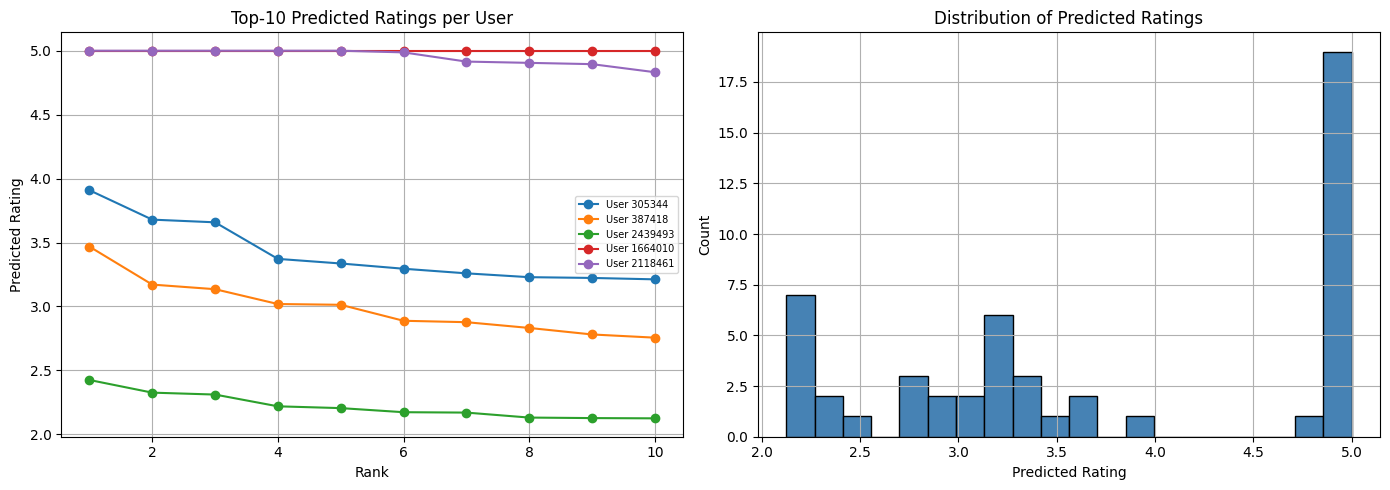

✅ Quality Plot Saved!


In [12]:
# ============================================================
# CELL 10: RECOMMENDATION QUALITY PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for user in sample_users:
    u = rec_df[rec_df['user_id'] == user]
    axes[0].plot(u['rank'], u['predicted_rating'], marker='o', label=f'User {user}')
axes[0].set_title('Top-10 Predicted Ratings per User')
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Predicted Rating')
axes[0].legend(fontsize=7)
axes[0].grid(True)

axes[1].hist(rec_df['predicted_rating'], bins=20, color='steelblue', edgecolor='black')
axes[1].set_title('Distribution of Predicted Ratings')
axes[1].set_xlabel('Predicted Rating')
axes[1].set_ylabel('Count')
axes[1].grid(True)

plt.tight_layout()
plt.savefig(RESULTS_PATH + "recommendation_quality.png", dpi=150)
plt.show()
print("✅ Quality Plot Saved!")

In [13]:
# ============================================================
# CELL 11: EXPLAINABLE RECOMMENDATIONS (Optional A)
# ============================================================
print("🔍 EXPLAINABLE RECOMMENDATIONS\n")
print("=" * 55)

for user in sample_users[:3]:
    top_rated = train_df[train_df['user_id'] == user].nlargest(3, 'rating')
    print(f"\n👤 User {user} liked:")
    for _, row in top_rated.iterrows():
        t = df_movies[df_movies['movie_id'] == row['movie_id']]['title'].values
        print(f"   ⭐ {t[0] if len(t)>0 else row['movie_id']} (rated {row['rating']})")

    print(f"   → Therefore recommended:")
    for _, row in rec_df[rec_df['user_id'] == user].head(3).iterrows():
        print(f"   🎬 {row['title']} (predicted: {row['predicted_rating']})")

print("\n✅ Explanation: SVD learns latent user preferences from")
print("   rating patterns and recommends movies matching those")
print("   hidden factors — genre, tone, director style, etc.")

🔍 EXPLAINABLE RECOMMENDATIONS


👤 User 305344 liked:
   ⭐ The Three Stooges: Stooged and Confoosed (rated 5.0)
   ⭐ The Who: The Kids Are Alright (rated 5.0)
   ⭐ Total Recall (rated 5.0)
   → Therefore recommended:
   🎬 Harold and Kumar Go to White Castle (predicted: 3.909)
   🎬 Star Trek: Voyager: Season 5 (predicted: 3.679)
   🎬 Emma (Miniseries) (predicted: 3.658)

👤 User 387418 liked:
   ⭐ Snake & Crane Arts of Shaolin (rated 5.0)
   ⭐ The Hitchhiker's Guide to the Galaxy (rated 5.0)
   ⭐ Finding Neverland (rated 5.0)
   → Therefore recommended:
   🎬 The Matrix: Revolutions (predicted: 3.468)
   🎬 Sweet November (predicted: 3.171)
   🎬 Invader Zim (predicted: 3.135)

👤 User 2439493 liked:
   ⭐ Over There (Pilot) (rated 5.0)
   ⭐ On Golden Pond (rated 5.0)
   ⭐ Lorenzo's Oil (rated 5.0)
   → Therefore recommended:
   🎬 Pay It Forward (predicted: 2.425)
   🎬 ABC Primetime: Mel Gibson's The Passion of the Christ (predicted: 2.326)
   🎬 Invader Zim (predicted: 2.311)

✅ Explanation: S

In [14]:
# ============================================================
# CELL 12: COLD START STRATEGY (Optional B)
# ============================================================
print("=" * 55)
print("❄️  COLD START STRATEGY")
print("=" * 55)

print("""
PROBLEM: New users / new movies have no ratings.
SVD and Item-CF both fail without interaction history.

STRATEGIES IMPLEMENTED (Discussion):

1. NEW USER — Popularity-Based Fallback
   → Recommend globally top-rated movies until
     enough ratings collected (>10 ratings).

2. NEW MOVIE — Content-Based Metadata
   → Use genre/title similarity to find similar
     known movies and transfer their ratings.

3. SPARSE USER — Hybrid Weighting
   → Blend SVD prediction with popularity score:
     final_score = α × SVD + (1-α) × popularity
     where α increases as user rates more movies.
""")

# Popularity-based fallback demo
top_popular = df.groupby('movie_id')['rating'].agg(['mean','count'])
top_popular = top_popular[top_popular['count'] > 100].sort_values('mean', ascending=False).head(10)

print("📋 Cold Start Fallback — Top 10 by Avg Rating (>100 reviews):")
for mid, row in top_popular.iterrows():
    t = df_movies[df_movies['movie_id'] == mid]['title'].values
    print(f"   🎬 {t[0][:40] if len(t)>0 else mid}  avg={row['mean']:.2f}  votes={int(row['count'])}")

print("\n✅ Cold Start Strategy Complete!")

❄️  COLD START STRATEGY

PROBLEM: New users / new movies have no ratings.
SVD and Item-CF both fail without interaction history.

STRATEGIES IMPLEMENTED (Discussion):

1. NEW USER — Popularity-Based Fallback
   → Recommend globally top-rated movies until
     enough ratings collected (>10 ratings).

2. NEW MOVIE — Content-Based Metadata
   → Use genre/title similarity to find similar
     known movies and transfer their ratings.

3. SPARSE USER — Hybrid Weighting
   → Blend SVD prediction with popularity score:
     final_score = α × SVD + (1-α) × popularity
     where α increases as user rates more movies.

📋 Cold Start Fallback — Top 10 by Avg Rating (>100 reviews):
   🎬 The Lord of the Rings: The Fellowship of  avg=4.72  votes=8798
   🎬 Lord of the Rings: The Return of the Kin  avg=4.72  votes=8750
   🎬 Lord of the Rings: The Two Towers: Exten  avg=4.70  votes=9057
   🎬 Battlestar Galactica: Season 1  avg=4.68  votes=214
   🎬 Lost: Season 1  avg=4.68  votes=930
   🎬 Samurai Champloo

In [15]:
# ============================================================
# CELL 13: FINAL SUMMARY
# ============================================================
print("=" * 60)
print("🏁 PROJECT COMPLETE — FINAL SUMMARY")
print("=" * 60)
print(f"""
DATASET     : Netflix Prize (10M ratings subset)
USERS       : {df['user_id'].nunique():,}
MOVIES      : {df['movie_id'].nunique():,}
SPARSITY    : {sparsity*100:.2f}%
SPLIT       : 80% train / 20% test

MODELS TRAINED:
  1. SVD (Matrix Factorization)
     - Factors: 50 | Epochs: 20
     - RMSE: {rmse_svd:.4f} | MAE: {mae_svd:.4f} | MAP@10: {map10_svd:.4f}

  2. Item-Based Collaborative Filtering
     - Cosine similarity on 1M sample
     - RMSE: {rmse_cf:.4f} | MAE: {mae_cf:.4f} | MAP@10: {map10_cf:.4f}

WINNER      : SVD (better ranking quality — MAP@10)

OPTIONAL TASKS DONE:
  ✅ Explainable Recommendations
  ✅ Cold Start Strategy

SAVED FILES:
  ✅ eda_complete.png
  ✅ model_comparison_final.png
  ✅ recommendation_quality.png
""")
print("=" * 60)

🏁 PROJECT COMPLETE — FINAL SUMMARY

DATASET     : Netflix Prize (10M ratings subset)
USERS       : 458,341
MOVIES      : 14,596
SPARSITY    : 99.85%
SPLIT       : 80% train / 20% test

MODELS TRAINED:
  1. SVD (Matrix Factorization)
     - Factors: 50 | Epochs: 20
     - RMSE: 0.9414 | MAE: 0.7354 | MAP@10: 0.0015

  2. Item-Based Collaborative Filtering
     - Cosine similarity on 1M sample
     - RMSE: 1.0481 | MAE: 0.8211 | MAP@10: 0.0003

WINNER      : SVD (better ranking quality — MAP@10)

OPTIONAL TASKS DONE:
  ✅ Explainable Recommendations
  ✅ Cold Start Strategy

SAVED FILES:
  ✅ eda_complete.png
  ✅ model_comparison_final.png
  ✅ recommendation_quality.png



In [16]:
!pip install gradio -q
print("✅ Gradio installed!")

✅ Gradio installed!


In [18]:
# ============================================================
# CELL 14: INTERACTIVE DASHBOARD - NETFLIX STYLE UI
# ============================================================
import gradio as gr
import numpy as np

def get_recommendations(user_id_str, n_recs):
    try:
        user_id = int(user_id_str)
    except:
        return "<p style='color:#E50914'>❌ Valid User ID daalo</p>"

    if user_id not in train_df['user_id'].values:
        return "<p style='color:#E50914'>❌ User ID dataset mein nahi hai</p>"

    user_rated = set(train_df[train_df['user_id'] == user_id]['movie_id'].tolist())
    unrated    = [m for m in df_movies['movie_id'].tolist() if m not in user_rated][:500]
    preds      = [(m, svd_model.predict(user_id, m).est) for m in unrated]
    top_n      = sorted(preds, key=lambda x: x[1], reverse=True)[:int(n_recs)]

    cards = ""
    for rank, (mid, score) in enumerate(top_n, 1):
        title  = df_movies[df_movies['movie_id'] == mid]['title'].values
        title  = title[0] if len(title) > 0 else 'Unknown'
        stars  = "⭐" * int(round(score))
        pct    = int((score / 5) * 100)
        color  = "#E50914" if score >= 4.0 else "#f5c518" if score >= 3.0 else "#888"
        cards += f"""
        <div style="
            background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
            border: 1px solid #333;
            border-left: 4px solid {color};
            border-radius: 12px;
            padding: 16px 20px;
            margin: 8px 0;
            display: flex;
            align-items: center;
            gap: 16px;
            transition: transform 0.2s;
        ">
            <div style="
                background: {color};
                color: white;
                font-size: 20px;
                font-weight: 900;
                width: 48px;
                height: 48px;
                border-radius: 50%;
                display: flex;
                align-items: center;
                justify-content: center;
                flex-shrink: 0;
            ">#{rank}</div>
            <div style="flex: 1;">
                <div style="color: white; font-size: 16px; font-weight: 700; margin-bottom: 4px;">{title}</div>
                <div style="color: #aaa; font-size: 13px;">{stars}</div>
            </div>
            <div style="text-align: right;">
                <div style="color: {color}; font-size: 24px; font-weight: 900;">{score:.2f}</div>
                <div style="color: #888; font-size: 11px;">/ 5.00</div>
                <div style="
                    background: #333;
                    border-radius: 4px;
                    height: 4px;
                    width: 80px;
                    margin-top: 4px;
                ">
                    <div style="
                        background: {color};
                        width: {pct}%;
                        height: 4px;
                        border-radius: 4px;
                    "></div>
                </div>
            </div>
        </div>"""

    return f"""
    <div style="font-family: 'Netflix Sans', Arial, sans-serif; padding: 10px;">
        <h2 style="color: #E50914; margin-bottom: 4px;">🎬 Top {int(n_recs)} picks for User {user_id}</h2>
        <p style="color: #888; margin-bottom: 16px; font-size: 13px;">Personalized by SVD Matrix Factorization</p>
        {cards}
    </div>"""

def get_similar_movies(movie_name, n_similar):
    matches = df_movies[df_movies['title'].str.contains(movie_name, case=False, na=False)]
    if len(matches) == 0:
        return "<p style='color:#E50914'>❌ Movie nahi mili</p>"

    mid = matches.iloc[0]['movie_id']
    if mid not in idx_movie:
        return "<p style='color:#E50914'>❌ Similarity matrix mein nahi hai</p>"

    base_title = matches.iloc[0]['title']
    sim_row    = item_sim[idx_movie[mid]].toarray().flatten()
    top_idx    = sim_row.argsort()[::-1][1:int(n_similar)+1]

    cards = ""
    for rank, i in enumerate(top_idx, 1):
        m     = movie_idx[i]
        title = df_movies[df_movies['movie_id'] == m]['title'].values
        title = title[0] if len(title) > 0 else 'Unknown'
        sim   = sim_row[i]
        pct   = int(sim * 100)
        color = "#E50914" if sim >= 0.5 else "#f5c518" if sim >= 0.2 else "#888"
        cards += f"""
        <div style="
            background: linear-gradient(135deg, #1a1a2e 0%, #16213e 100%);
            border: 1px solid #333;
            border-left: 4px solid {color};
            border-radius: 12px;
            padding: 16px 20px;
            margin: 8px 0;
            display: flex;
            align-items: center;
            gap: 16px;
        ">
            <div style="
                background: {color};
                color: white;
                font-size: 18px;
                font-weight: 900;
                width: 48px;
                height: 48px;
                border-radius: 50%;
                display: flex;
                align-items: center;
                justify-content: center;
                flex-shrink: 0;
            ">#{rank}</div>
            <div style="flex: 1;">
                <div style="color: white; font-size: 16px; font-weight: 700;">{title}</div>
                <div style="color: #aaa; font-size: 12px; margin-top: 4px;">Similarity Score</div>
                <div style="
                    background: #333;
                    border-radius: 4px;
                    height: 6px;
                    width: 200px;
                    margin-top: 6px;
                ">
                    <div style="
                        background: linear-gradient(90deg, {color}, #ff6b6b);
                        width: {pct}%;
                        height: 6px;
                        border-radius: 4px;
                    "></div>
                </div>
            </div>
            <div style="
                color: {color};
                font-size: 22px;
                font-weight: 900;
            ">{sim:.4f}</div>
        </div>"""

    return f"""
    <div style="font-family: Arial, sans-serif; padding: 10px;">
        <h2 style="color: #E50914; margin-bottom: 4px;">🔍 Similar to: {base_title}</h2>
        <p style="color: #888; margin-bottom: 16px; font-size: 13px;">Based on Item-CF Cosine Similarity</p>
        {cards}
    </div>"""

def analyze_scores(user_id_str):
    try:
        user_id = int(user_id_str)
    except:
        return "<p style='color:#E50914'>❌ Valid User ID daalo</p>"

    if user_id not in train_df['user_id'].values:
        return "<p style='color:#E50914'>❌ User ID dataset mein nahi hai</p>"

    user_rated = set(train_df[train_df['user_id'] == user_id]['movie_id'].tolist())
    unrated    = [m for m in df_movies['movie_id'].tolist() if m not in user_rated][:300]
    preds      = [svd_model.predict(user_id, m).est for m in unrated]

    avg_p  = np.mean(preds)
    max_p  = np.max(preds)
    min_p  = np.min(preds)
    above4 = sum(p > 4.0 for p in preds)
    above35= sum(p > 3.5 for p in preds)

    def stat_card(label, value, color="#E50914"):
        return f"""
        <div style="
            background: linear-gradient(135deg, #1a1a2e, #16213e);
            border: 1px solid #333;
            border-top: 3px solid {color};
            border-radius: 12px;
            padding: 20px;
            text-align: center;
            flex: 1;
            min-width: 120px;
        ">
            <div style="color: {color}; font-size: 28px; font-weight: 900;">{value}</div>
            <div style="color: #aaa; font-size: 12px; margin-top: 6px;">{label}</div>
        </div>"""

    return f"""
    <div style="font-family: Arial, sans-serif; padding: 10px;">
        <h2 style="color: #E50914; margin-bottom: 4px;">📊 Score Analysis — User {user_id}</h2>
        <p style="color: #888; margin-bottom: 20px; font-size: 13px;">SVD prediction distribution</p>
        <div style="display: flex; gap: 12px; flex-wrap: wrap;">
            {stat_card("Movies Rated", len(user_rated), "#E50914")}
            {stat_card("Avg Predicted", f"{avg_p:.2f}", "#f5c518")}
            {stat_card("Max Predicted", f"{max_p:.2f}", "#46d369")}
            {stat_card("Min Predicted", f"{min_p:.2f}", "#888")}
            {stat_card("Above 4.0 ⭐", above4, "#E50914")}
            {stat_card("Above 3.5 ⭐", above35, "#f5c518")}
        </div>
    </div>"""

sample_ids = train_df['user_id'].value_counts().index[:5].tolist()

css = """
body { background-color: #141414 !important; }
.gradio-container {
    background: #141414 !important;
    font-family: Arial, sans-serif;
}
.tab-nav button {
    color: #aaa !important;
    background: transparent !important;
    border-bottom: 2px solid transparent !important;
    font-size: 15px !important;
    font-weight: 600 !important;
}
.tab-nav button.selected {
    color: white !important;
    border-bottom: 2px solid #E50914 !important;
}
input, textarea {
    background: #2a2a2a !important;
    color: white !important;
    border: 1px solid #444 !important;
    border-radius: 8px !important;
}
button.primary {
    background: #E50914 !important;
    border: none !important;
    border-radius: 8px !important;
    font-weight: 700 !important;
    font-size: 15px !important;
}
button.primary:hover { background: #b20710 !important; }
.block { background: #1a1a1a !important; border: none !important; }
"""

with gr.Blocks(css=css, title="🎬 Netflix Recommendation System") as demo:
    gr.HTML("""
    <div style="
        background: linear-gradient(90deg, #E50914, #b20710);
        padding: 24px 32px;
        border-radius: 12px;
        margin-bottom: 8px;
        display: flex;
        align-items: center;
        gap: 16px;
    ">
        <div style="font-size: 48px;">🎬</div>
        <div>
            <h1 style="color: white; margin: 0; font-size: 28px; font-weight: 900; letter-spacing: 1px;">
                NETFLIX RECOMMENDATION ENGINE
            </h1>
            <p style="color: rgba(255,255,255,0.8); margin: 4px 0 0; font-size: 14px;">
                Powered by SVD Matrix Factorization + Item-Based Collaborative Filtering
            </p>
        </div>
    </div>
    """)

    gr.HTML(f"""
    <div style="
        background: #1a1a2e;
        border: 1px solid #333;
        border-radius: 10px;
        padding: 12px 20px;
        margin-bottom: 8px;
        color: #aaa;
        font-size: 13px;
    ">
        💡 <b style="color: white;">Sample User IDs:</b>
        <span style="color: #E50914; font-weight: bold;">{', '.join(map(str, sample_ids))}</span>
        &nbsp;&nbsp;|&nbsp;&nbsp;
        🎬 <b style="color: white;">Sample Movies:</b>
        <span style="color: #f5c518;">Matrix, Titanic, Shrek, Batman</span>
    </div>
    """)

    with gr.Tab("🎯 Recommendations"):
        with gr.Row():
            uid1 = gr.Textbox(label="User ID", placeholder="e.g. 305344", scale=3)
            n1   = gr.Slider(5, 20, value=10, step=1, label="Number of Results", scale=2)
        btn1 = gr.Button("🚀 Get My Recommendations", variant="primary")
        out1 = gr.HTML()
        btn1.click(get_recommendations, inputs=[uid1, n1], outputs=out1)

    with gr.Tab("🔍 Similar Movies"):
        with gr.Row():
            movie_input = gr.Textbox(label="Movie Name", placeholder="e.g. Matrix", scale=3)
            n2          = gr.Slider(5, 20, value=10, step=1, label="Number of Results", scale=2)
        btn2 = gr.Button("🔍 Find Similar Movies", variant="primary")
        out2 = gr.HTML()
        btn2.click(get_similar_movies, inputs=[movie_input, n2], outputs=out2)

    with gr.Tab("📊 Score Analysis"):
        uid3 = gr.Textbox(label="User ID", placeholder="e.g. 305344")
        btn3 = gr.Button("📊 Analyze My Scores", variant="primary")
        out3 = gr.HTML()
        btn3.click(analyze_scores, inputs=[uid3], outputs=out3)

demo.launch(share=True)
print("✅ Netflix-Style Dashboard Live!")

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://032cf7c88111d9c615.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


✅ Netflix-Style Dashboard Live!
